In [1]:
from src.features.credit_features import build_internal_oas_proxy
from src.features.macro_features import build_macro_features
from src.signals.regime import build_regime_signal
from src.config import load_config
from src.data_loader import load_bond_data

config = load_config("config/base.yaml")
df = load_bond_data(config)

internal_oas = build_internal_oas_proxy(
    df,
    method=config["features"]["oas_proxy_method"],
    z_window=config["features"]["z_window"],
)
macro_features = build_macro_features(config, internal_oas)
regime = build_regime_signal(macro_features, config)

regime

Dropped 1 rows with missing Date/OAS.


,regime_score,regime
Date,,
2010-01-01,NaN,unknown
2010-02-01,NaN,unknown
2010-03-01,NaN,unknown
2010-04-01,NaN,unknown
2010-05-01,NaN,unknown
...,...,...
2025-11-01,-0.068723,neutral
2025-12-01,-0.364269,neutral
2026-01-01,-0.242325,neutral


<Axes: title={'center': 'Macro Regime Score'}, xlabel='Date'>

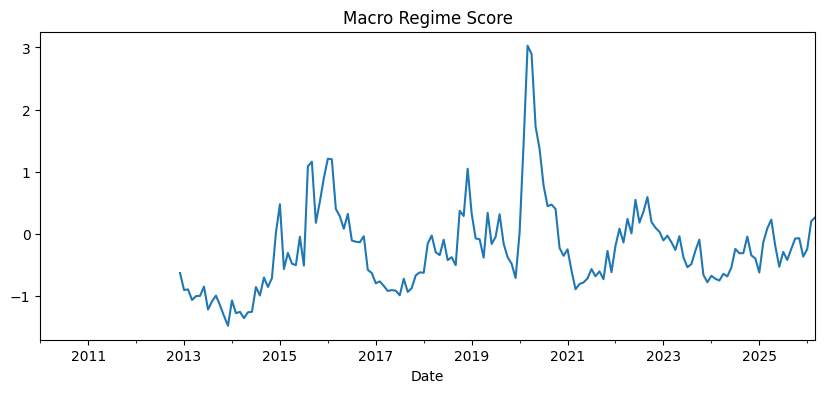

In [2]:
regime["regime_score"].plot(title="Macro Regime Score", figsize=(10, 4))

In [3]:
regime["regime"].value_counts()

regime
neutral     114
unknown      35
risk_on      34
risk_off     12
Name: count, dtype: int64

In [4]:
from src.signals.bond_signal import build_bond_signal

signal_df = build_bond_signal(df, regime, config)

signal_df[[
    "Date",
    "ISIN",
    "Ticker",
    "Eff_Rating_Group",
    "Class2",
    "regime",
    "OAS",
    "DTS",
    "OAD",
    "Yield_To_Worst",
    "signal_score",
    "next_excess_return",
]].head()

,Date,ISIN,Ticker,Eff_Rating_Group,Class2,regime,OAS,DTS,OAD,Yield_To_Worst,signal_score,next_excess_return
64674,2012-12-01,CA65548PAC01,BAMACN,BB,Industrial,neutral,363.9,8.14,2.24,4.088,0.006011,1.93
64532,2012-12-01,US000361AQ86,AIR,BB,Industrial,neutral,461.9,25.03,5.65,6.206,-0.288916,2.02
64478,2012-12-01,US00081TAH14,ACCO,B,Industrial,neutral,457.5,23.71,5.40,5.793,-0.481975,2.48
64441,2012-12-01,US00088JAB98,21380Z,CCC,Industrial,neutral,948.7,20.34,2.17,10.077,-0.524899,1.34
64488,2012-12-01,US00101DAA72,ADSI,B,Industrial,neutral,946.6,35.16,3.78,10.396,0.085690,1.73


In [5]:
print(signal_df.index.name)
print(signal_df.index.names)
print(signal_df.columns.tolist()[:10])
signal_df.head()

None
[None]
['Date', 'Cusip', 'ISIN', 'Class1', 'Class2', 'Class3', 'Ticker', 'Eff_Rating_Group', 'Index_Rating_Number', 'Maturity_Date']


,Date,Cusip,ISIN,Class1,Class2,Class3,Ticker,Eff_Rating_Group,Index_Rating_Number,Maturity_Date,...,oas_z,dts_z,oad_z,yield_to_worst_z,regime_score,regime,rating_penalty,risk_multiplier,ccc_flag,signal_score
64674,2012-12-01,65548PAC,CA65548PAC01,Corporate,Industrial,Basic_Industry,BAMACN,BB,14,1/1/1900,...,-0.420471,-0.795259,-0.701833,-0.476693,-0.62791,neutral,0.00,1.0,0,0.006011
64532,2012-12-01,000361AQ,US000361AQ86,Corporate,Industrial,Capital_Goods,AIR,BB,14,1/1/1900,...,-0.225517,0.181962,0.753114,-0.106074,-0.62791,neutral,0.00,1.0,0,-0.288916
64478,2012-12-01,00081TAH,US00081TAH14,Corporate,Industrial,Consumer_Non_Cyclical,ACCO,B,15,1/1/1900,...,-0.234270,0.105589,0.646447,-0.178343,-0.62791,neutral,-0.20,1.0,0,-0.481975
64441,2012-12-01,00088JAB,US00088JAB98,Corporate,Industrial,Transportation,21380Z,CCC,18,1/1/1900,...,0.742887,-0.089392,-0.731700,0.571295,-0.62791,neutral,-0.75,1.0,1,-0.524899
64488,2012-12-01,00101DAA,US00101DAA72,Corporate,Industrial,Capital_Goods,ADSI,B,17,1/1/1900,...,0.738709,0.768063,-0.044760,0.627116,-0.62791,neutral,-0.20,1.0,0,0.085690


In [6]:
from src.portfolio.construction import build_portfolio, summarize_portfolio_exposures

portfolio = build_portfolio(signal_df, config)

portfolio.head()

,Date,Cusip,ISIN,Class1,Class2,Class3,Ticker,Eff_Rating_Group,Index_Rating_Number,Maturity_Date,...,dts_z,oad_z,yield_to_worst_z,regime_score,regime,rating_penalty,risk_multiplier,ccc_flag,signal_score,target_weight
0,2012-12-01,87255MAA,US87255MAA80,Corporate,Industrial,Communications,TLACQ,CCC,21,1/1/1900,...,4.870193,-1.000503,13.245143,-0.62791,neutral,-0.75,1.0,1,7.226976,0.011700
1,2012-12-01,87255MAD,US87255MAD20,Corporate,Industrial,Communications,TLACQ,CCC,21,1/1/1900,...,5.141546,-0.957836,12.942418,-0.62791,neutral,-0.75,1.0,1,6.936269,0.011700
2,2012-12-01,882330AH,US882330AH60,Corporate,Utility,Electric,TXU,CCC,22,1/1/1900,...,7.112767,-0.753034,13.198422,-0.62791,neutral,-0.75,1.0,1,6.475070,0.029798
3,2012-12-01,882330AG,US882330AG87,Corporate,Utility,Electric,TXU,CCC,22,1/1/1900,...,6.325899,-0.765834,11.813237,-0.62791,neutral,-0.75,1.0,1,5.769486,0.029798
4,2012-12-01,882330AF,US882330AF05,Corporate,Utility,Electric,TXU,CCC,22,1/1/1900,...,6.188776,-0.761567,11.436668,-0.62791,neutral,-0.75,1.0,1,5.549694,0.029798


In [7]:
print("Shape:", portfolio.shape)
print("Date range:", portfolio["Date"].min(), "to", portfolio["Date"].max())
print("Months:", portfolio["Date"].nunique())
print("Avg bonds/month:", portfolio.groupby("Date")["ISIN"].nunique().mean())

Shape: (31854, 30)
Date range: 2012-12-01 00:00:00 to 2026-02-01 00:00:00
Months: 159
Avg bonds/month: 200.33962264150944


In [8]:
weight_sums = portfolio.groupby("Date")["target_weight"].sum()

weight_sums.describe()

count    1.590000e+02
mean     1.000000e+00
std      1.572575e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: target_weight, dtype: float64

In [9]:
from src.portfolio.backtest import run_backtest

backtest = run_backtest(portfolio)

backtest

,portfolio_excess_return,cumulative_excess_return,wealth_index,running_peak,drawdown
Date,,,,,
2012-12-01,0.045426,0.045426,1.045426,1.045426,0.000000
2013-01-01,-0.031073,0.012941,1.012941,1.045426,-0.031073
2013-02-01,-0.021503,-0.008840,0.991160,1.045426,-0.051908
2013-03-01,0.045427,0.036186,1.036186,1.045426,-0.008839
2013-04-01,0.036246,0.073744,1.073744,1.073744,0.000000
...,...,...,...,...,...
2025-10-01,-0.002634,2.741487,3.741487,4.879785,-0.233268
2025-11-01,0.014672,2.796381,3.796381,4.879785,-0.222019
2025-12-01,0.023016,2.883760,3.883760,4.879785,-0.204112


In [10]:
from src.evaluation.metrics import (
    compute_performance_metrics,
    compute_turnover,
    combine_metrics,
)

metrics = compute_performance_metrics(backtest)
turnover = compute_turnover(portfolio)
summary = combine_metrics(backtest, portfolio)

summary

start_date                  2012-12-01 00:00:00
end_date                    2026-02-01 00:00:00
n_months                                    159
annualized_excess_return               0.275048
annualized_volatility                  0.859857
sharpe_ratio                           0.319877
cumulative_excess_return               2.836099
max_drawdown                           -0.84083
hit_rate                               0.515723
best_month                              2.72806
worst_month                           -0.324251
avg_monthly_return                     0.022921
avg_monthly_turnover                   0.315303
max_monthly_turnover                   0.925886
dtype: object

In [12]:
from src.evaluation.plots import save_all_plots
from src.evaluation.metrics import compute_turnover
from src.portfolio.construction import summarize_portfolio_exposures

turnover = compute_turnover(portfolio)
exposures = summarize_portfolio_exposures(portfolio)

save_all_plots(
    backtest=backtest,
    turnover=turnover,
    exposures=exposures,
    regime=regime,
)